X shape: (30000, 35), y shape: (30000,)
Taux de défaut: 22.12%
Train: 21000
Validation: 4500
Test: 4500
Taux défaut train: 22.12%
Taux défaut val: 22.11%
Taux défaut test: 22.13%
✅ Scaler sauvegardé !

=== Logistic Regression ===
Matrice de confusion:
[[3390  114]
 [ 820  176]]
Accuracy: 0.7924
Precision: 0.6069
Recall: 0.1767
F1-score: 0.2737
ROC-AUC: 0.7194

=== Decision Tree ===
Matrice de confusion:
[[3289  215]
 [ 676  320]]
Accuracy: 0.8020
Precision: 0.5981
Recall: 0.3213
F1-score: 0.4180
ROC-AUC: 0.7443

=== Random Forest ===
Matrice de confusion:
[[3336  168]
 [ 733  263]]
Accuracy: 0.7998
Precision: 0.6102
Recall: 0.2641
F1-score: 0.3686
ROC-AUC: 0.7646

=== XGBoost ===
Matrice de confusion:
[[3315  189]
 [ 688  308]]
Accuracy: 0.8051
Precision: 0.6197
Recall: 0.3092
F1-score: 0.4126
ROC-AUC: 0.7709

=== RÉSULTATS COMPARATIFS ===
                Modèle  Accuracy  Precision  Recall  F1-score  ROC-AUC
0  Logistic Regression    0.7924     0.6069  0.1767    0.2737   0.7194
1     

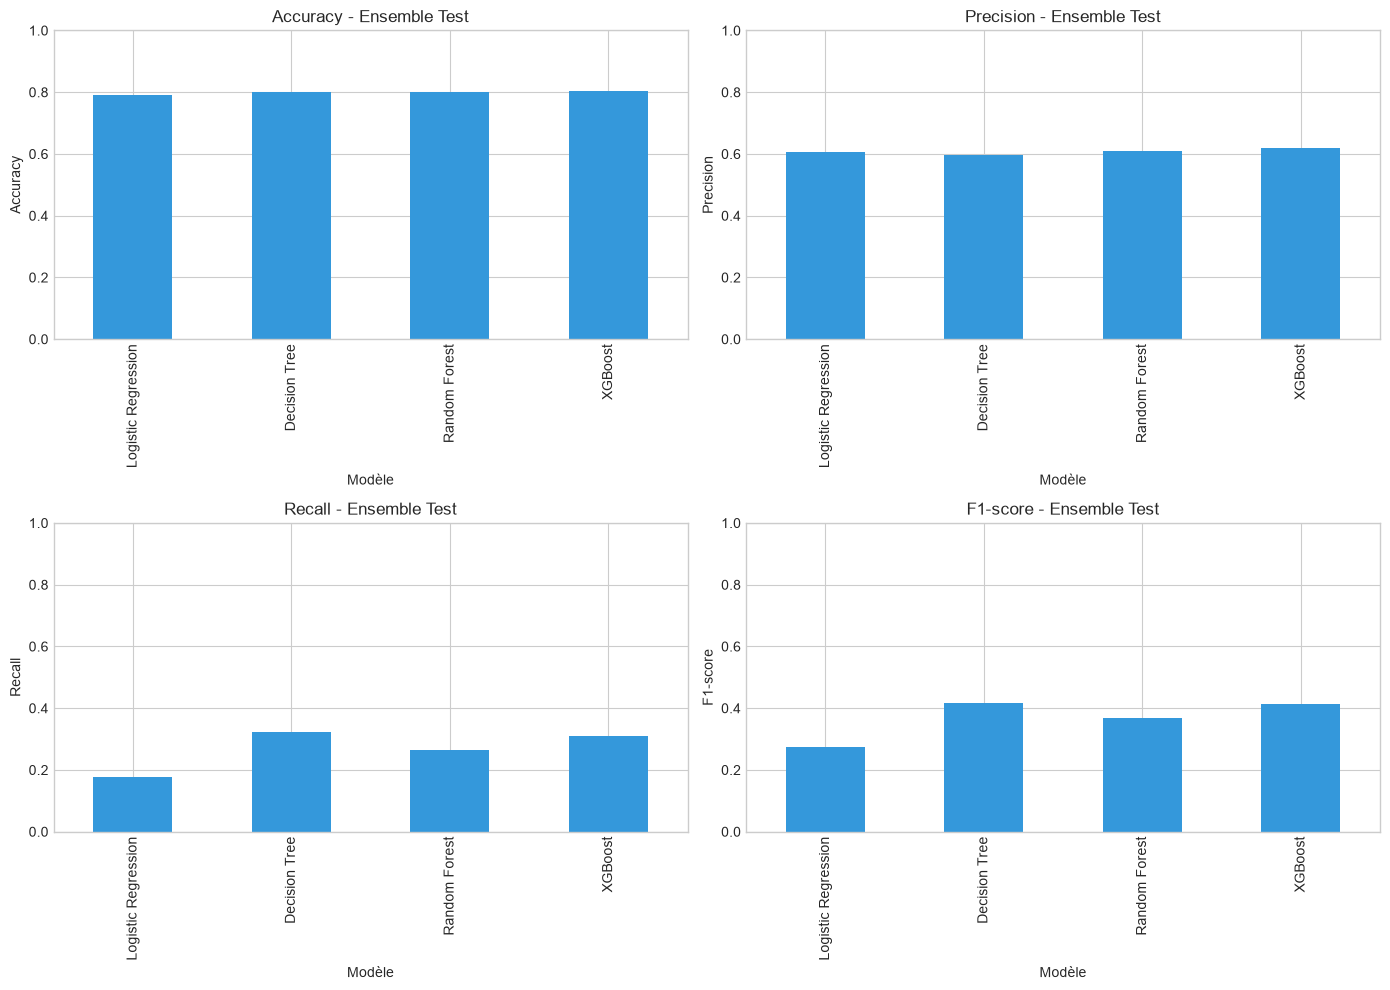

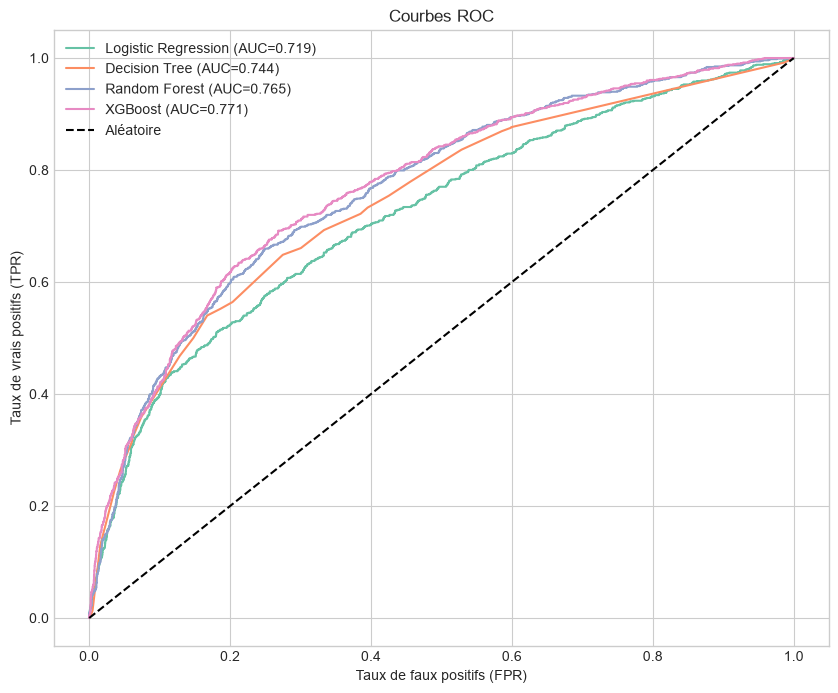

✅ Meilleur modèle sauvegardé !
✅ Feature names sauvegardés !


In [2]:
# %% [markdown]
# # 04 - Model Experiments
# ## Projet : AI Credit Risk Prediction Platform
# ## Dataset : UCI Default of Credit Card Clients

# %% [markdown]
# ### 1. Import des librairies

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve, 
                             confusion_matrix, classification_report)
from imblearn.over_sampling import SMOTE
import joblib

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# %% [markdown]
# ### 2. Chargement des données

# %%
X = pd.read_csv('../data/processed/X_features.csv')
y = pd.read_csv('../data/processed/y_target.csv').values.ravel()

print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Taux de défaut: {y.mean()*100:.2f}%")

# %% [markdown]
# ### 3. Séparation des données

# %%
# Split 70/15/15
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape[0]}")
print(f"Validation: {X_val.shape[0]}")
print(f"Test: {X_test.shape[0]}")
print(f"Taux défaut train: {y_train.mean()*100:.2f}%")
print(f"Taux défaut val: {y_val.mean()*100:.2f}%")
print(f"Taux défaut test: {y_test.mean()*100:.2f}%")

# %% [markdown]
# ### 4. Standardisation des données

# %%
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, '../models/scaler.pkl')
print("✅ Scaler sauvegardé !")

# %% [markdown]
# ### 5. Définition et entraînement des modèles

# %%
# Définition des modèles
models = {
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, min_samples_split=2, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, use_label_encoder=False, eval_metric='logloss')
}

# %% [markdown]
# ### 6. Entraînement et évaluation

# %%
results = []

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"=== {name} ===")
    
    # Entraînement
    model.fit(X_train_scaled, y_train)
    
    # Prédictions
    y_pred_test = model.predict(X_test_scaled)
    y_proba_test = model.predict_proba(X_test_scaled)[:, 1]
    
    # Métriques
    acc = accuracy_score(y_test, y_pred_test)
    prec = precision_score(y_test, y_pred_test)
    rec = recall_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test)
    auc = roc_auc_score(y_test, y_proba_test)
    
    results.append({
        'Modèle': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1,
        'ROC-AUC': auc
    })
    
    # Matrice de confusion
    cm = confusion_matrix(y_test, y_pred_test)
    print(f"Matrice de confusion:\n{cm}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"ROC-AUC: {auc:.4f}")

# %% [markdown]
# ### 7. Tableau comparatif des modèles

# %%
results_df = pd.DataFrame(results)
print("\n=== RÉSULTATS COMPARATIFS ===")
print(results_df.round(4))

# Sauvegarde
results_df.to_csv('../data/processed/model_results.csv', index=False)

# %% [markdown]
# ### 8. Visualisation des résultats

# %%
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']

for idx, metric in enumerate(metrics):
    row, col = idx // 2, idx % 2
    results_df.plot(kind='bar', x='Modèle', y=metric, ax=axes[row, col], 
                    color='#3498db', legend=False)
    axes[row, col].set_title(f'{metric} - Ensemble Test')
    axes[row, col].set_ylabel(metric)
    axes[row, col].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('../data/processed/model_comparison.png', dpi=150)
plt.show()

# %% [markdown]
# ### 9. Courbes ROC

# %%
plt.figure(figsize=(10, 8))

for name, model in models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire')
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbes ROC')
plt.legend()
plt.grid(True)
plt.savefig('../data/processed/roc_curves.png', dpi=150)
plt.show()

# %% [markdown]
# ### 10. Sauvegarde du meilleur modèle

# %%
# Le meilleur modèle est généralement XGBoost
best_model = models['XGBoost']
joblib.dump(best_model, '../models/xgboost_final.pkl')
print("✅ Meilleur modèle sauvegardé !")

# Sauvegarder aussi les noms des features
feature_names = X.columns.tolist()
with open('../models/feature_names.txt', 'w') as f:
    for feat in feature_names:
        f.write(f"{feat}\n")
print("✅ Feature names sauvegardés !")